### データサイエンス実践A 2025 第10講 (11/4) 講義資料
1. 複合グラフ  
1. 両y軸グラフ  
1. エラーバーの描画

In [1]:
# 数値演算、描画用ライブラリ読み込み
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# グラフをinline表示可能にする
%matplotlib inline

# 解像度を上げてinline表示する
%config InlineBackend.figure_format = 'retina'

# 日本語表示用ライブラリ（matplotlibで日本語を使用したい場合）
try:
  import japanize_matplotlib
except ModuleNotFoundError:
  # 初回だけインストールするので時間がかかる
  !pip install japanize-matplotlib
  import japanize_matplotlib

### データ取得
+ [新潟（新潟県) 2024年（月ごとの値）【気象庁】](https://www.data.jma.go.jp/stats/etrn/view/monthly_s1.php?prec_no=54&block_no=47604&year=2024&month=&day=10&view=p1)  
+ [第2回課題用Excelファイル](https://ccs-kumanolab.com/lecture/dsa/kadai2.xlsx)  (kadai2.xlsx)  
の２ファイルをホームディレクトリにダウンロード（下のセルを実行すれば自動でDLできる）

In [2]:
# おまじない追加（ネット情報取得用ライブラリ） 
import urllib.request

# Excelファイルのネット上のアドレスを指定（熊野研サーバーからファイル取得）
url1 = 'https://ccs-kumanolab.com/lecture/dsa/ngt2024_temp_rain.xlsx'
url2 = 'https://ccs-kumanolab.com/lecture/dsa/kadai2.xlsx'

# 指定URLから Excelファイル の取得＆読み込み
urllib.request.urlretrieve(url1, '新潟気温降水量2024.xlsx')
urllib.request.urlretrieve(url2, 'kadai2.xlsx')

('kadai2.xlsx', <http.client.HTTPMessage at 0x198d3817490>)

In [3]:
# 新潟（新潟県) 2024年（月ごとの値）データ読み込み
df = pd.read_excel('新潟気温降水量2024.xlsx')
df

,月,降水量,平均気温
0,1,180.0,4.3
1,2,114.5,4.8
2,3,168.0,6.0
3,4,54.0,13.7
4,5,128.0,17.1
5,6,57.0,22.2
6,7,376.5,26.2
7,8,42.0,28.0
8,9,292.0,25.0
9,10,144.5,18.7


### 複合グラフ（例：棒グラフと折れ線グラフ）
主な用途例：
+ 観測値（棒グラフ）と平均値（折れ線グラフ）の比較　など
+ 実験値（棒グラフ）と理論値・モデル（折れ線グラフ）の比較

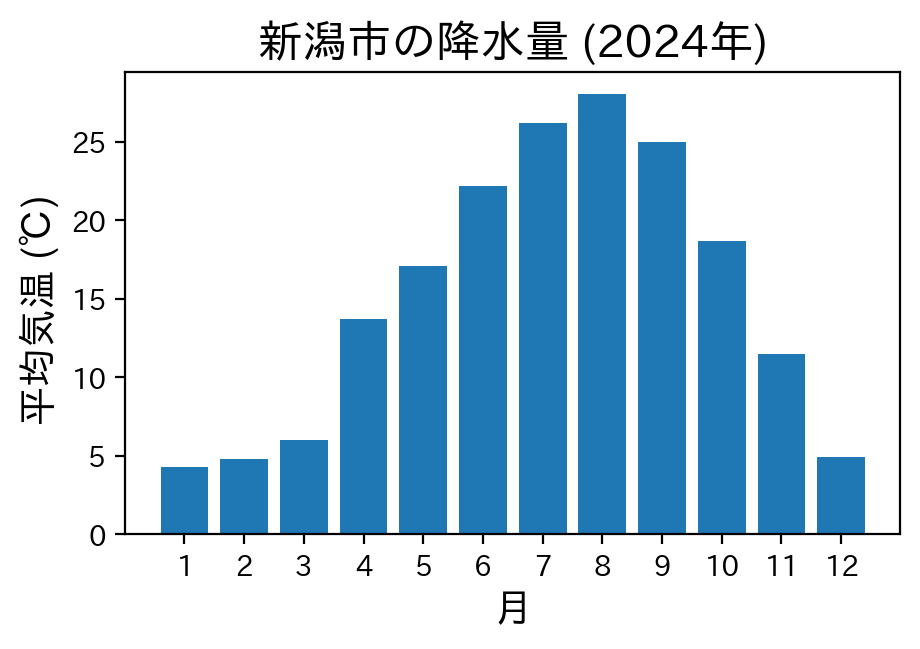

In [4]:
# データ準備（.to_numpy() はなくてもよい！)
month = df['月']
rain = df['降水量']
temp = df['平均気温']

# 棒グラフの作成
plt.figure(figsize=(5,3))
plt.bar(month, temp)

# 必要な情報追加
plt.title('新潟市の降水量 (2024年)', fontsize=16)
plt.xlabel('月', fontsize=14)
plt.ylabel("平均気温 (℃) ", fontsize=14)
plt.xticks(range(1,13))

# グラフ描画
plt.show()

### 複合グラフ（棒グラフ＋折れ線グラフ）の描画
数値範囲や単位等が両グラフで同じ場合

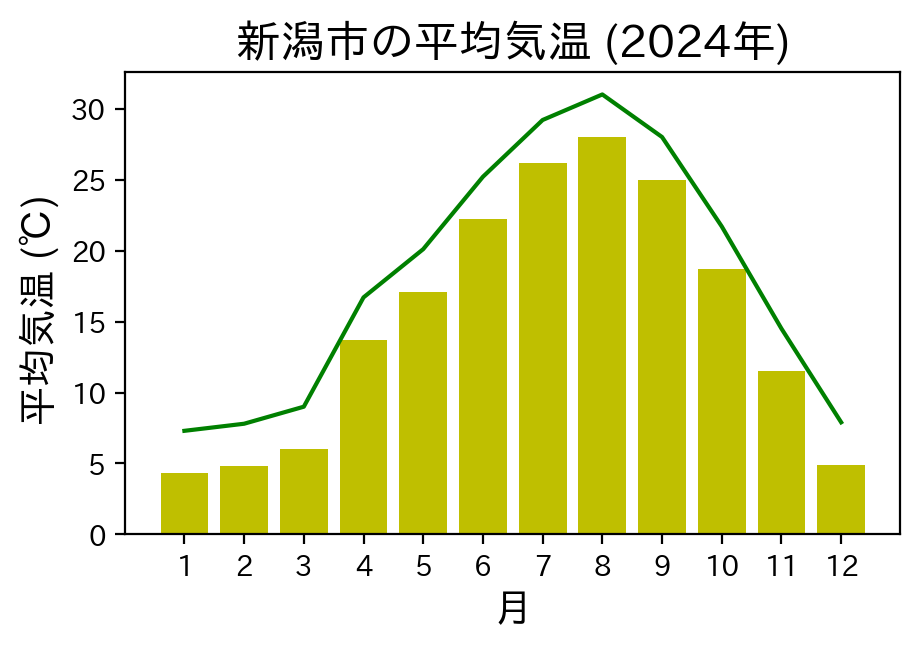

In [5]:
# 棒グラフの作成
plt.figure(figsize=(5,3))
plt.bar(month, temp, color='y')

# 折れ線グラフの作成
# 例えば平年値や新潟県内の全観測点の平均のようなものを想定（今は単に +3 としてある）
plt.plot(month, temp + 3, c='g')

# 必要な情報追加
plt.title('新潟市の平均気温 (2024年)', fontsize=16)
plt.xlabel('月',fontsize=14)
plt.ylabel("平均気温 (℃) ", fontsize=14)
plt.xticks(range(1,13))

# グラフ描画
plt.show()

### 両y軸グラフ（右軸の追加）
数値範囲や単位等が両グラフで異なる場合

In [6]:
# データを用意（データサイエンス概説テキスト 表1.1）
weight = np.array([43.6, 45.2, 45.4, 45.8, 47.2, 47.8, 48.2, 48.7, 48.8, 48.9, 49.0, 49.0, 49.4,
                   49.5, 49.8, 50.4, 50.5, 50.9, 50.9, 51.2, 51.2, 51.2, 51.3, 51.3, 51.6, 51.7,
                   51.7, 51.8, 52.0, 52.0, 52.1, 52.1, 52.1, 52.2, 52.3, 52.7, 52.7, 52.8, 52.9,
                   52.9, 53.1, 53.1, 53.8, 54.0, 54.5, 54.5, 54.6, 54.7, 54.7, 54.7, 54.8, 54.9,
                   55.1, 55.1, 55.2, 55.3, 55.4, 55.4, 55.4, 55.6, 55.7, 55.8, 55.9, 56.1, 56.3,
                   56.3, 56.3, 56.4, 56.5, 56.7, 56.8, 57.0, 57.1, 57.1, 57.2, 57.3, 57.6, 57.7,
                   57.8, 58.1, 58.4, 58.6, 58.7, 58.7, 58.7, 58.7, 59.1, 59.3, 59.9, 60.0, 60.1,
                   60.3, 60.5, 60.6, 60.6, 60.7, 61.3, 62.7, 64.2, 64.6])

# 階級の境界値を設定
hist_ini = 43; hist_fin = 66; hist_step = 2
bins = np.arange(hist_ini, hist_fin, hist_step)

dosu, cls = np.histogram(weight, bins)
cum_dosu = np.cumsum(dosu)
print(cls)      # 階級 (=bins)
print(dosu)     # 度数
print(cum_dosu) # 累積度数

[43 45 47 49 51 53 55 57 59 61 63 65]
[ 1  3  6  9 21 12 19 15 10  2  2]
[  1   4  10  19  40  52  71  86  96  98 100]


In [7]:
#（参考）度数分布表の作成
import pandas as pd
s=pd.DataFrame([cls,dosu, cum_dosu], index=["階級", "度数", "累積度数"])
s

,0,1,2,3,4,5,6,7,8,9,10,11
階級,43,45,47,49,51,53,55,57,59,61,63,65.0
度数,1,3,6,9,21,12,19,15,10,2,2,NaN
累積度数,1,4,10,19,40,52,71,86,96,98,100,NaN


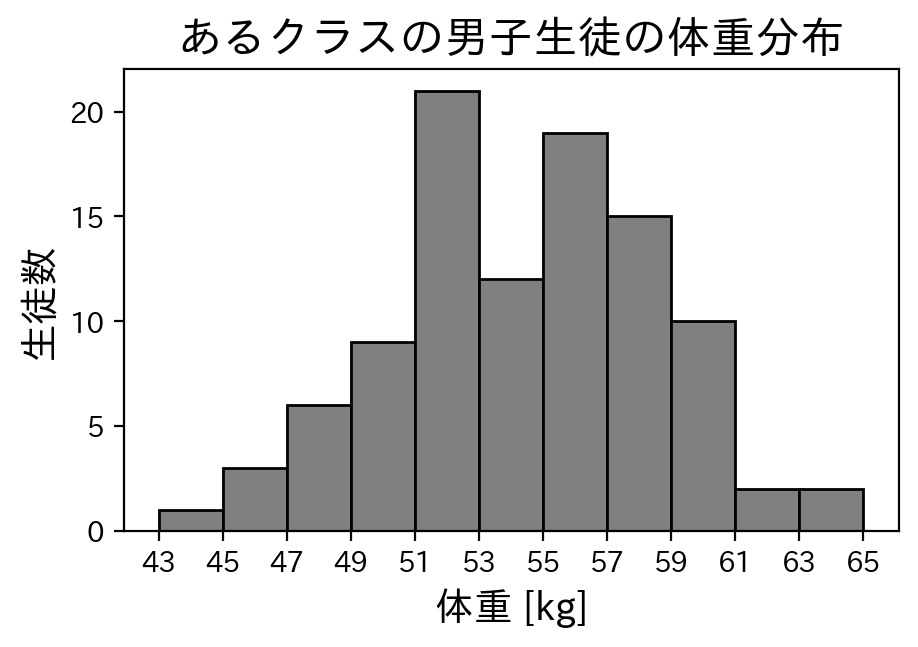

In [8]:
# ヒストグラムの描画
plt.figure(figsize=(5,3))
plt.hist(weight, bins=bins, color="gray", ec="black")

# グラフに必要な情報を追加して完成
plt.xticks(bins)
plt.yticks(np.arange(0,21,5))
plt.title("あるクラスの男子生徒の体重分布", fontsize=16)
plt.xlabel("体重 [kg]", fontsize=14)
plt.ylabel("生徒数", fontsize=14)

# グラフ描画
plt.show()

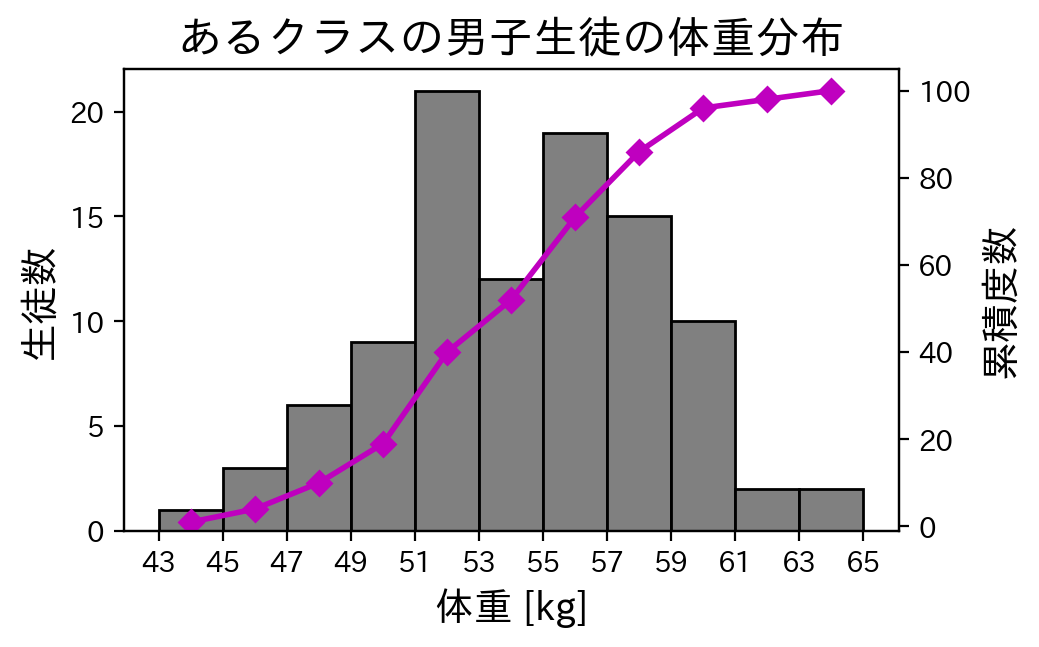

In [9]:
# ヒストグラムの描画
plt.figure(figsize=(5,3))
plt.hist(weight, bins=bins, color="gray", ec="black")

# グラフに必要な情報を追加
plt.xticks(bins)
plt.yticks(np.arange(0,21,5))
plt.title("あるクラスの男子生徒の体重分布", fontsize=16)
plt.xlabel("体重 [kg]", fontsize=14)
plt.ylabel("生徒数", fontsize=14)

# 2軸グラフ（右軸の付加）
plt.twinx()
plt.ylim(-1,105)
plt.ylabel("累積度数", fontsize=14)
plt.plot(np.delete(bins,-1) + hist_step/2, cum_dosu, "mD-", lw=2)

# グラフ描画
plt.show()

### 棒グラフで書き直す
ヒストグラムの場合、棒全体の色指定しかできない。棒グラフは個別に指定可能。

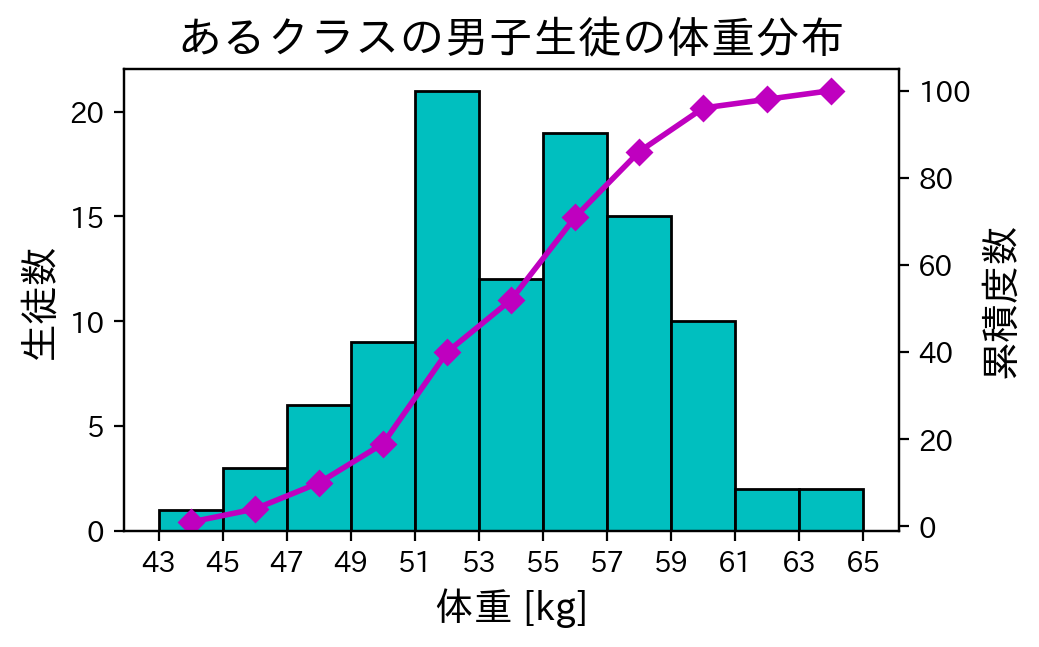

In [10]:
# 棒グラフの描画
plt.figure(figsize=(5,3))
plt.bar(np.delete(bins,-1), dosu, align='edge', color="c", ec="black", width=2)

plt.xticks(bins)
plt.yticks(np.arange(0,21,5))
plt.title("あるクラスの男子生徒の体重分布", fontsize=16)
plt.xlabel("体重 [kg]", fontsize=14)
plt.ylabel("生徒数", fontsize=14)

# 2軸グラフ（右軸の付加）
plt.twinx()
plt.ylim(-1,105)
plt.ylabel("累積度数", fontsize=14)
plt.plot(np.delete(bins,-1) + hist_step/2, cum_dosu, "mD-", lw=2)

# グラフ描画
plt.show()

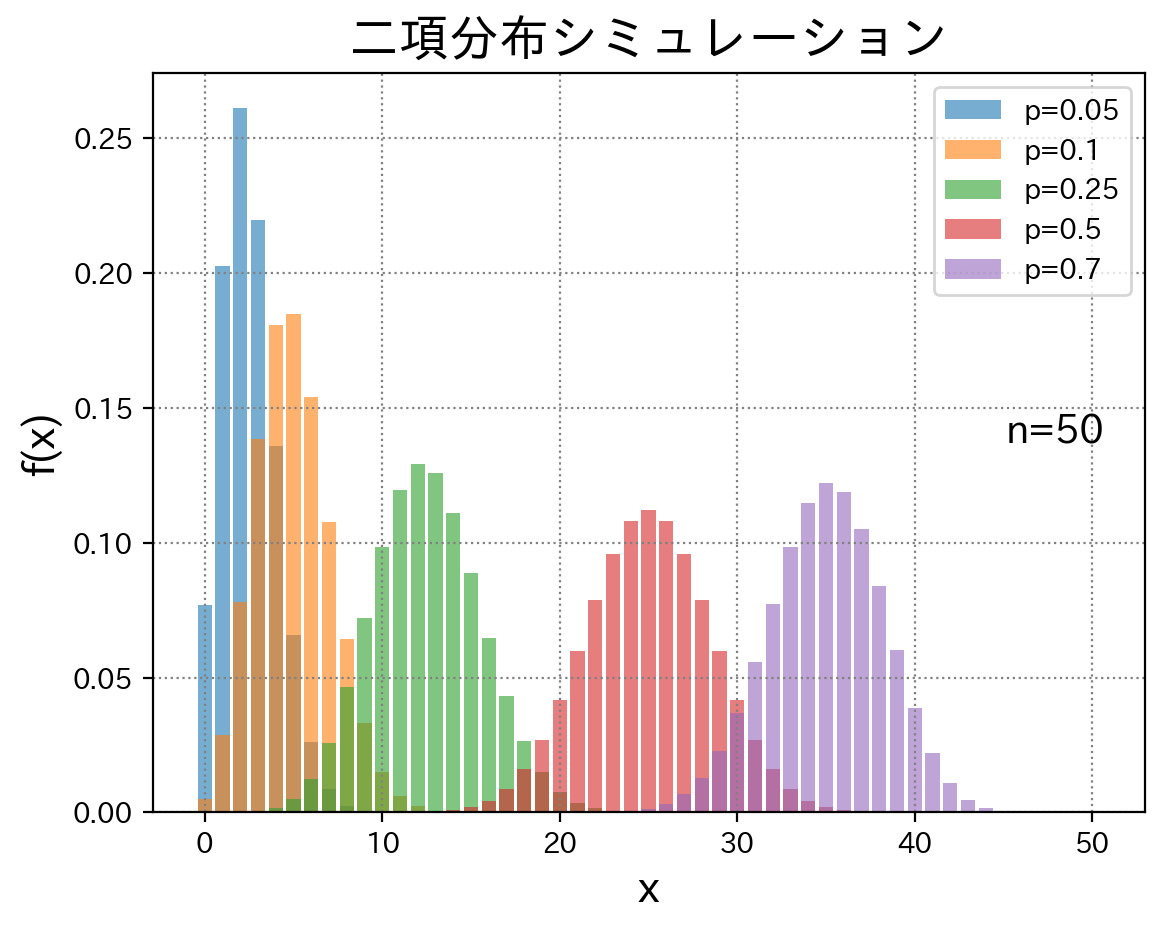

In [11]:
# 二項分布・正規分布を扱うライブラリをインポート
from scipy.stats import norm, binom

n=50    # 試行回数
p = [0.05, 0.1, 0.25, 0.5, 0.7]  # 成功確率(list)
x = np.arange(0,n+1)             # 成功回数(list)

# 複数のパラメータ(成功確率 p) を持つ二項分布を繰り返し作成
for k in p:
    y = binom.pmf(x,n,k)
    plt.bar(x, y, alpha=0.6, label=f'p={k}')

# 必要な情報追加
plt.title('二項分布シミュレーション', fontsize=18)
plt.xlabel('x', fontsize=16)
plt.ylabel('f(x)', fontsize=16)
plt.text(0.86, 0.5, f"n={n}", fontsize=14, transform=plt.gca().transAxes)
plt.grid(color='gray',linestyle=':')
plt.legend()

# グラフ描画
plt.show()

平均:  12.0   分散:  2.6832815729997477


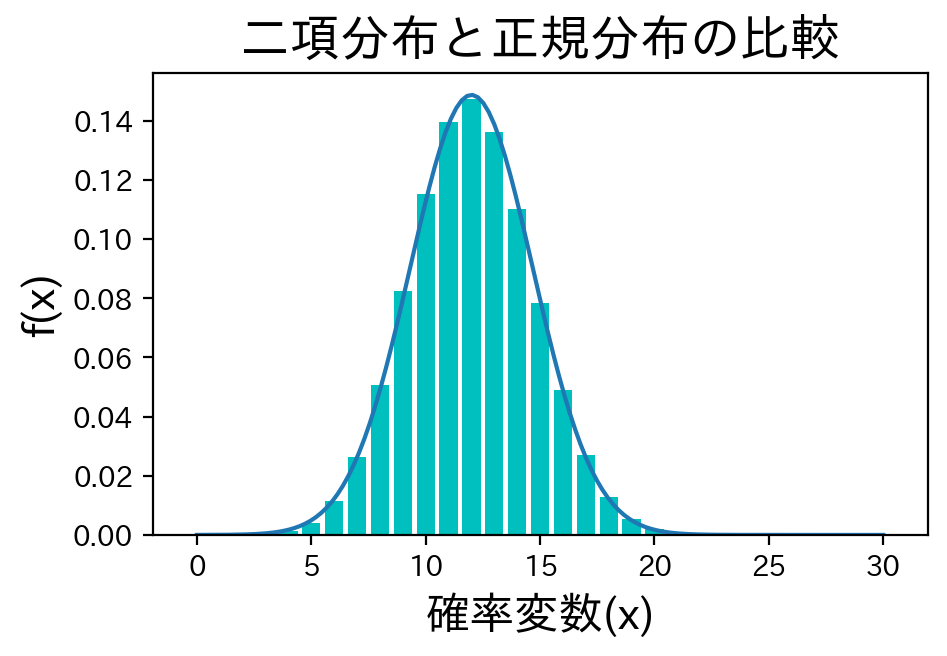

In [12]:
# ----- you can set values below -----
n = 30      # 試行回数
p = 0.4     # 成功確率 valid range: [0, 1]
# ------------------------------------

mu = n*p                   # 期待値
std = np.sqrt(n*p*(1-p))   # 分散

# 棒グラフの描画
x = np.arange(0, n+1)  # 成功回数(list)
y = binom.pmf(x,n,p)

# 棒グラフの描画
plt.figure(figsize=(5,3))
plt.bar(x, y, color="c")  # 二項分布

# 折れ線グラフの描画
x_norm = np.linspace(0,n,128)
plt.plot(x_norm, norm.pdf(x_norm, loc=mu, scale=std))  # 正規分布

plt.title('二項分布と正規分布の比較', fontsize=18)
plt.xlabel('確率変数(x)', fontsize=16)
plt.ylabel('f(x)', fontsize=16)
print("平均: ", mu, "  分散: ", std)

# グラフ描画
plt.show()

### twinx の描画順序について
twinxは、左軸に対するグラフが絶対的に優先される。 普通に zorder では変えられない。  
気象庁（新潟市）  
https://www.data.jma.go.jp/stats/etrn/view/monthly_s1.php?prec_no=54&block_no=47604&year=2024&month=&day=10&view=p1

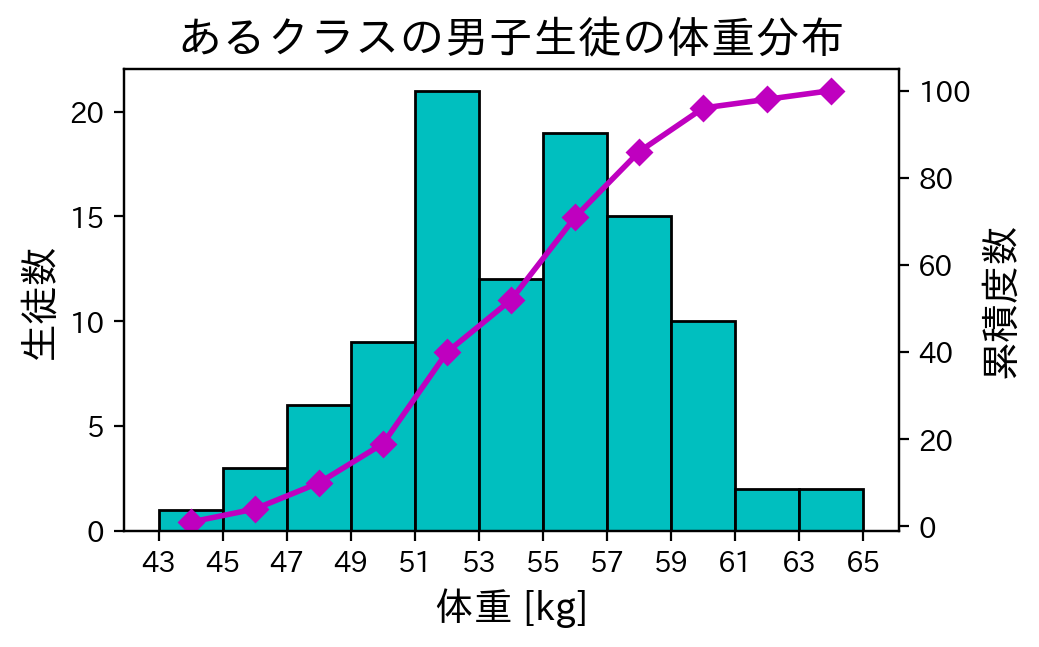

In [13]:
# 棒グラフの描画
plt.figure(figsize=(5,3))
plt.bar(np.delete(bins,-1), dosu, align='edge', color="c", ec="black", width=2)

plt.xticks(bins)
plt.yticks(np.arange(0,21,5))
plt.title("あるクラスの男子生徒の体重分布", fontsize=16)
plt.xlabel("体重 [kg]", fontsize=14)
plt.ylabel("生徒数", fontsize=14)

# 2軸グラフ（右軸の付加）
plt.twinx()
plt.ylim(-1,105)
plt.ylabel("累積度数", fontsize=14)
plt.plot(np.delete(bins,-1) + hist_step/2, cum_dosu, "mD-", lw=2)

# グラフ描画
plt.show()

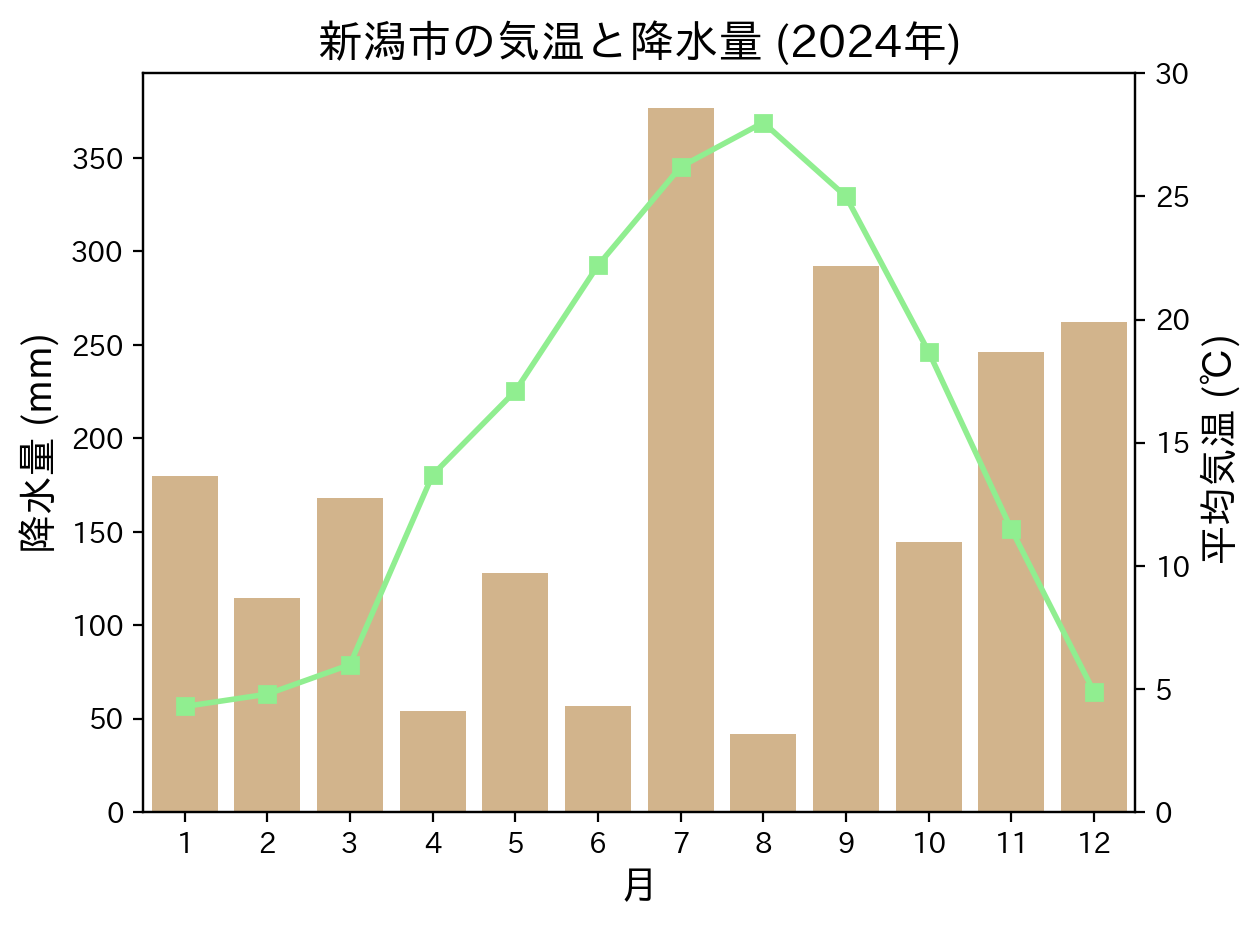

In [14]:
# 左軸に対するグラフ作成（棒グラフ）
plt.bar(month, rain, width=0.8, color='tan')

# 両軸に共通する情報の追加
plt.title('新潟市の気温と降水量 (2024年)', fontsize=16)
plt.xlabel('月',fontsize=14)
plt.xticks(month, range(1,13))
plt.xlim(0.5, 12.5)

# 左軸に対する情報の追加
plt.ylabel('降水量 (mm)',fontsize=14)

# 2軸グラフ（右軸の付加）
plt.twinx()

# 右軸に対するグラフ作成（折れ線グラフ）
plt.plot(month, temp, marker="s", c="lightgreen", lw=2)

# 右軸関連情報の追加
plt.ylabel("平均気温 (℃) ", fontsize=14)
plt.ylim(0,30)

# グラフ描画
plt.show()

### 平均気温を左軸に描こうとすると・・・
zorderでは変更できない。

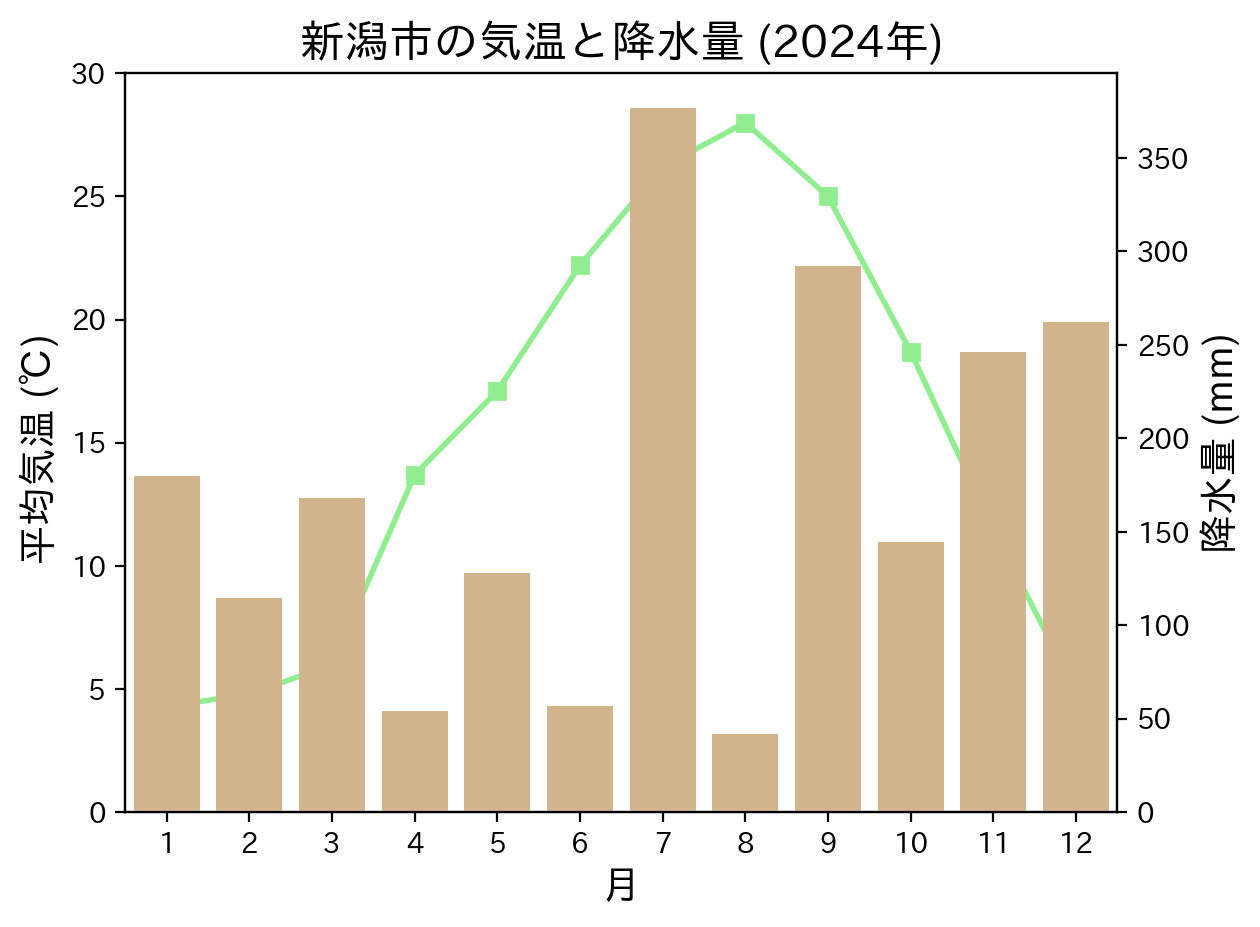

In [15]:
# 左軸に対するグラフ作成（折れ線グラフ）
plt.plot(month, temp, marker="s", c="lightgreen", lw=2)

# 両軸に共通する情報の追加
plt.title('新潟市の気温と降水量 (2024年)', fontsize=16)
plt.xlabel('月',fontsize=14)
plt.xticks(month, range(1,13))
plt.xlim(0.5, 12.5)

# 左軸に対する情報の追加
plt.ylim(0,30)
plt.ylabel("平均気温 (℃) ", fontsize=14)

# 2軸グラフ（右軸の付加）
plt.twinx()

# 右軸に対するグラフ作成（棒グラフ）
plt.bar(month, rain, width=0.8, color='tan')

# 右軸関連情報の追加
plt.ylabel('降水量 (mm)',fontsize=14)

# グラフ描画
plt.show()

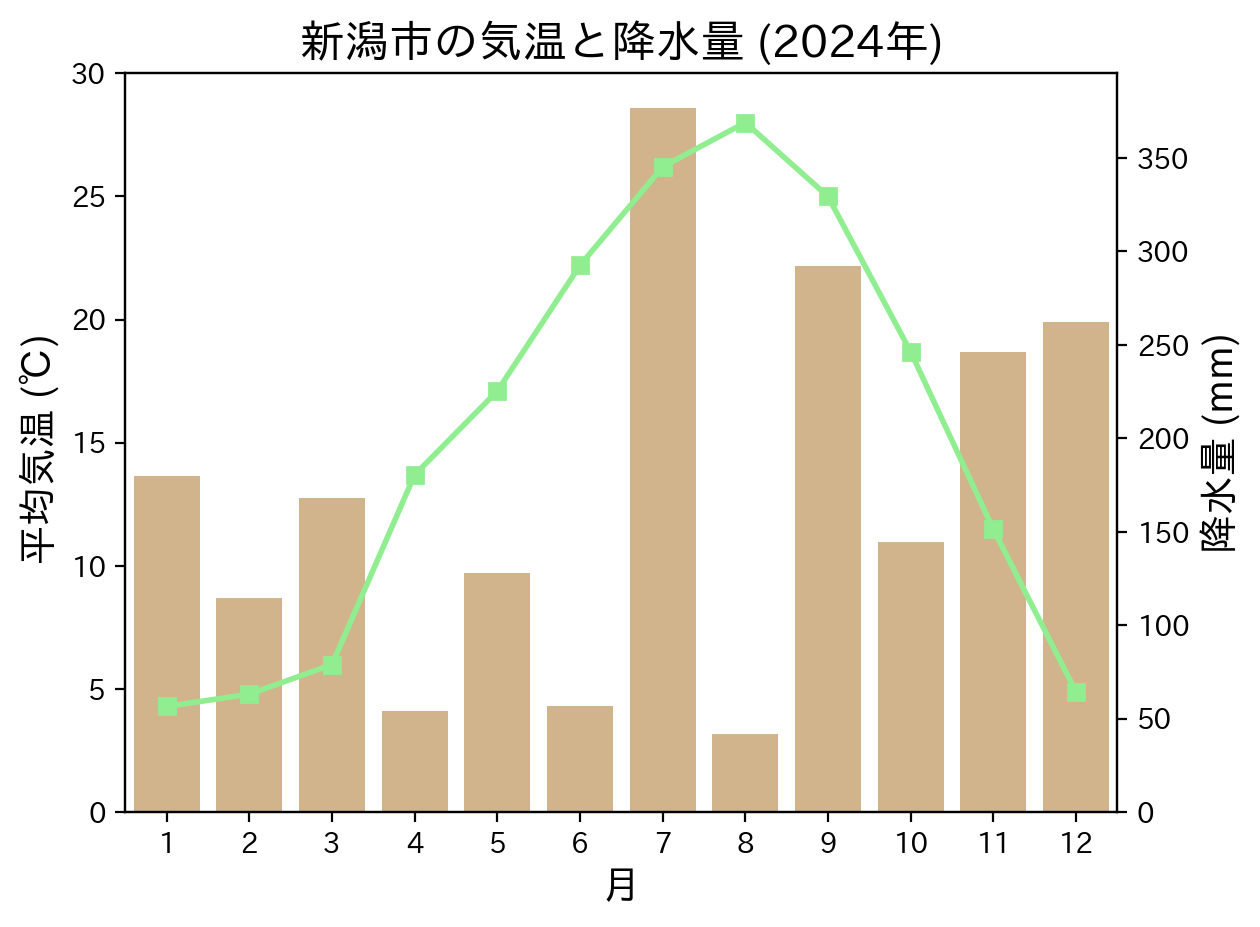

In [16]:
# 軸の描画順序の設定が必要
plt.gca().patch.set_alpha(0)  # 上層を透明化して下層も見えるように
plt.gca().set_zorder(2)       # 上層設定

# 左軸に対するグラフ作成（折れ線グラフ）
plt.plot(month, temp, marker="s", c="lightgreen", lw=2)

# 両軸に共通する情報の追加
plt.title('新潟市の気温と降水量 (2024年)', fontsize=16)
plt.xlabel('月',fontsize=14)
plt.xticks(month, range(1,13))
plt.xlim(0.5, 12.5)

# 左軸に対する情報の追加
plt.ylim(0,30)
plt.ylabel("平均気温 (℃) ", fontsize=14)

# 2軸グラフ（右軸の付加）
plt.twinx()

# 右軸に対するグラフ作成（棒グラフ）
plt.gca().set_zorder(1)      # 下層設定（通常はtwinx側が上層になる）
plt.bar(month, rain, width=0.8, color='tan')

# 右軸関連情報の追加
plt.ylabel('降水量 (mm)',fontsize=14)

# グラフ描画
plt.show()

#### エラーバーの描画
（注意！）エラーバーは、元の分布が正規分布でよく表されることを暗に仮定している

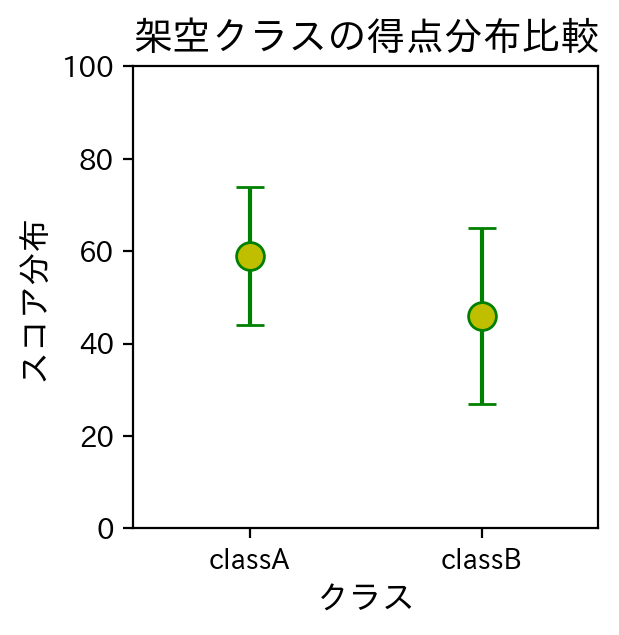

In [17]:
# データ作成（ダミー）
classes = ['classA', 'classB']
mean_score = [59, 46]
errorbar = [15, 19]

# 散布図の作成
plt.figure(figsize=(3,3))
#plt.scatter(classes, mean_score)

# エラーバー付き散布図の作成
plt.errorbar(classes, mean_score, yerr=errorbar, capsize=5, fmt='o', markersize=10, ecolor='g', markeredgecolor="g", color='y')

# グラフ軸範囲指定
plt.xlim(-0.5, 1.5)
plt.ylim(0, 100)

# グラフタイトル及び各軸の名称
plt.title('架空クラスの得点分布比較', fontsize=14)
plt.xlabel('クラス', fontsize=12)
plt.ylabel('スコア分布', fontsize=12)

# グラフ描画
plt.show()

In [18]:
# 乱数によるデータ生成（正規分布に従うデータ）
rng = np.random.default_rng(348309421) # seedの設定（空も可）
data = rng.normal(60, 17, 60)  # 平均65，標準偏差17の正規分布の乱数60個のnumpy.array型配列を作成
data

array([ 52.80198669,  58.81514194,  85.02206979,  79.09253409,
        50.87800638,  60.45625329,  74.7579895 ,  56.95091571,
        66.33964424,  63.70160737,  50.79540198,  56.21238431,
        92.10237915,  47.17576745,  53.03293403,  48.72109971,
        54.11198638,  68.61641901,  42.20030587,  48.57724871,
        69.56082482,  58.91515695,  52.48809338,  61.50964813,
        40.89255226,  39.40159728,  56.36238868, 111.42414393,
        23.84123697,  95.4203303 ,  65.49730947,  80.19914797,
        73.82512562,  39.550013  ,  34.30493881,  62.17531585,
        85.36138362,  65.42072436,  62.86769409,  36.59186269,
        51.23466921,  53.44844211,  59.98451359,  76.36516486,
        63.7815047 ,  60.7277623 ,  91.07561089,  65.52502446,
        76.77533222,  42.71676345,  30.36395212,  76.44873881,
        73.85558517,  16.86894139,  85.52242972,  63.22942773,
        62.39804608,  49.4758286 ,  51.80694558,  73.26142454])

[61 61 67 67 65 65 59 65 71 53 66 59 66 64 52 58 57 55 39 57 65 66 50 70
 60 61 55 58 71 58 64 56 62 43 58 47 74 62 68 27 71 68 50 82 66 79 56 34
 60 69 60 39 62 60 59 92 64 58 59 40 43 86 43 48 64 71 45 49 61 56 71 24
 44 60 62 62 73 82 67 69 37 72 82 63 57 51 56 63 77 48 50 73 53 69 59 60
 75 64 48 67]


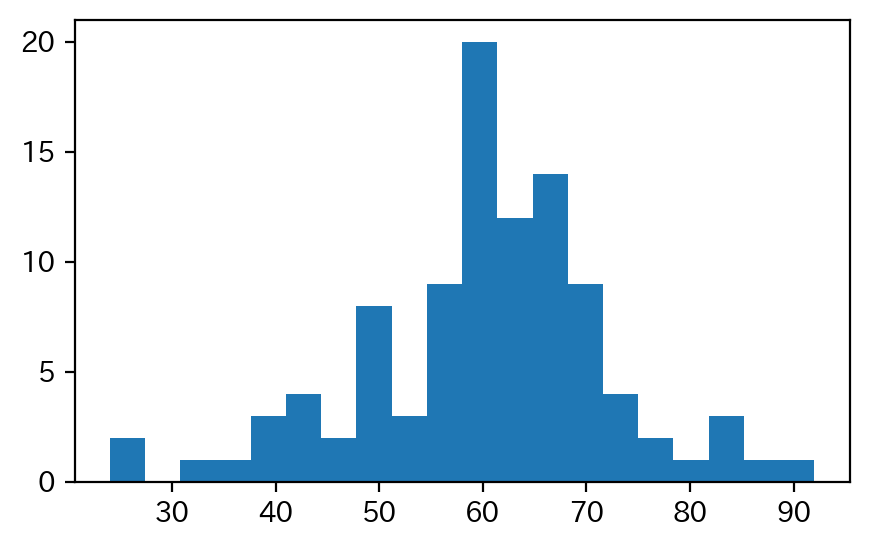

In [19]:
# 乱数でスコア（整数）分布を作成
plt.figure(figsize=(5,3))
d = np.random.normal(loc=60, scale=11.5, size=100).astype(int)
print(d)
plt.hist(d, bins=20)

# グラフ描画
plt.show()

In [20]:
# 2クラス分作成して以下のようになったとする
classA_score = np.array([61,64,68,46,61,69,62,73,60,55,65,49,41,73,79,68,73,64,70,61,60,39,55,
                         62,68,63,44,65,61,82,45,53,60,63,49,55,50,57,52,87,47,74,69,50,49,36,
                         70,51,55,65,53,62,60,43,49,86,64,78,78,28,61,74,54,54,69,34,56,64,70,
                         69,72,81,51,68,53,53,64,69,55,61,47,55,86,72,55,78,62,59,55,60,60,51,
                         58,45,63,63,72,82,61,55])

classB_score = np.array([57,76,75,62,66,57,70,67,78,67,55,72,79,61,56,76,72,69,71,76,69,71,73,
                         67,67,71,58,65,74,69,77,74,75,77,65,73,84,66,63,53,56,71,63,63,68,70,
                         77,69,73,62,64,57,79,79,64,57,66,83,64,61,68,57,48,69,67,57,58,71,73,
                         74,68,56,71,58,63,80,67,60,68,67,55,59,51,63,71,75,71,61,95,67,71,68,
                         72,61,67,73,60,65,81,64])

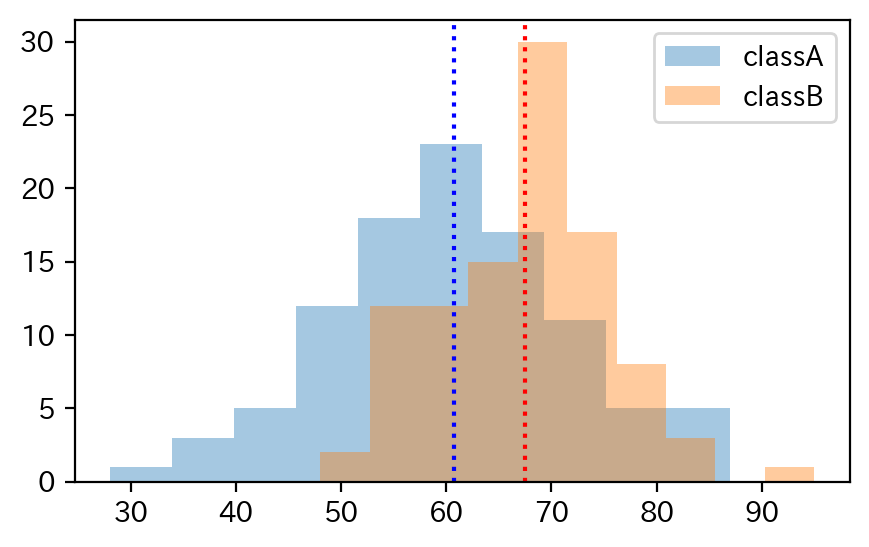

In [21]:
plt.figure(figsize=(5,3))

# ヒストグラム作成
plt.hist(classA_score, alpha=0.4, label='classA')
plt.hist(classB_score, alpha=0.4, label='classB')

# 各クラスの平均値を示す補助線作成
plt.axvline(x=classA_score.mean(), c='b', ls=':')
plt.axvline(x=classB_score.mean(), c='r', ls=':')
plt.legend()

# グラフ描画
plt.show()

In [22]:
# 平均値の計算
mean_A = classA_score.mean()
mean_B = classB_score.mean()

# 標準偏差（誤差棒の長さ）の計算
std_A = classA_score.std()
std_B = classB_score.std()

print(mean_A, std_A)
print(mean_B, std_B)

60.7 11.576268828944844
67.49 7.963033341635584


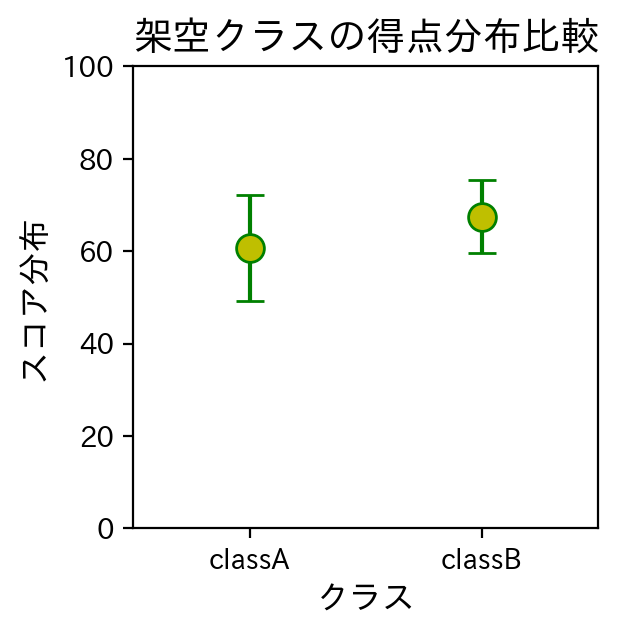

In [23]:
# データ作成（乱数生成データ）
classes = ['classA', 'classB']
mean_score = [mean_A, mean_B]
errorbar = [std_A, std_B]

# 散布図の作成
plt.figure(figsize=(3,3))
#plt.scatter(classes, mean_score)

# エラーバー付き散布図の作成
plt.errorbar(classes, mean_score, yerr=errorbar, capsize=5, fmt='o', markersize=10, ecolor='g', markeredgecolor="g", color='y')

# グラフ軸範囲指定
plt.xlim(-0.5, 1.5)
plt.ylim(0, 100)

# グラフタイトル及び各軸の名称
plt.title('架空クラスの得点分布比較', fontsize=14)
plt.xlabel('クラス', fontsize=12)
plt.ylabel('スコア分布', fontsize=12)

# グラフ描画
plt.show()

区間 [-1.0*sigma, 1.0*sigma]に入る確率: 0.683


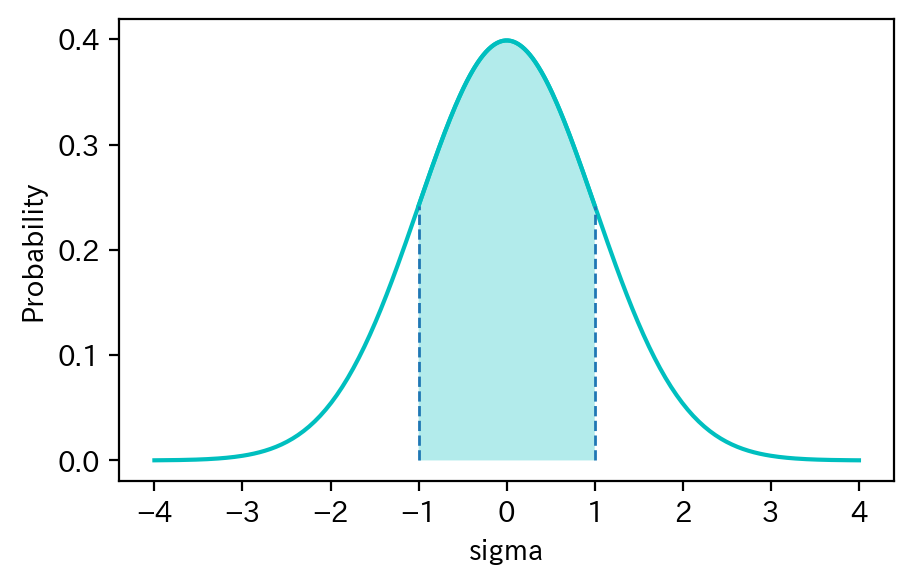

In [24]:
# 正規分布を扱うライブラリをインポート
from scipy.stats import norm

# 正規分布のパラメータ設定
center = 0
sigma = 1
z_pos = 1

# 正規分布データ作成
x1 = np.linspace(center - 4*sigma, center + 4*sigma, 2**8)
y1 = norm.pdf(x1, loc=center, scale=sigma)
x2 = np.linspace(center - z_pos*sigma, center + z_pos*sigma, 2**8)
y2 = norm.pdf(x2, loc=center, scale=sigma)

# 折れ線グラフ作成
plt.figure(figsize=(5,3))
plt.plot(x1, y1, color="c")
plt.plot(x2, y2, color="c")
plt.fill_between(x2, 0, y2, facecolor='c', alpha=0.3)

# 垂直補助線（ある点までの補助線）
plt.vlines(x=-z_pos, ymin=-0, ymax=norm.pdf(z_pos,loc=center,scale=sigma),
           linestyles='dashed', linewidths=1)
plt.vlines(x=z_pos, ymin=-0, ymax=norm.pdf(z_pos,loc=center,scale=sigma),
           linestyles='dashed', linewidths=1)

# ラベル情報の追加
plt.xlabel("sigma")
plt.ylabel("Probability")

# 色塗り範囲の確率計算
prob = 2*norm.cdf(x=z_pos, loc=center, scale=sigma)-1
print(f"区間 [{-z_pos: .1f}*sigma,{z_pos: .1f}*sigma]に入る確率:{prob: .3f}")

# グラフ描画
plt.show()

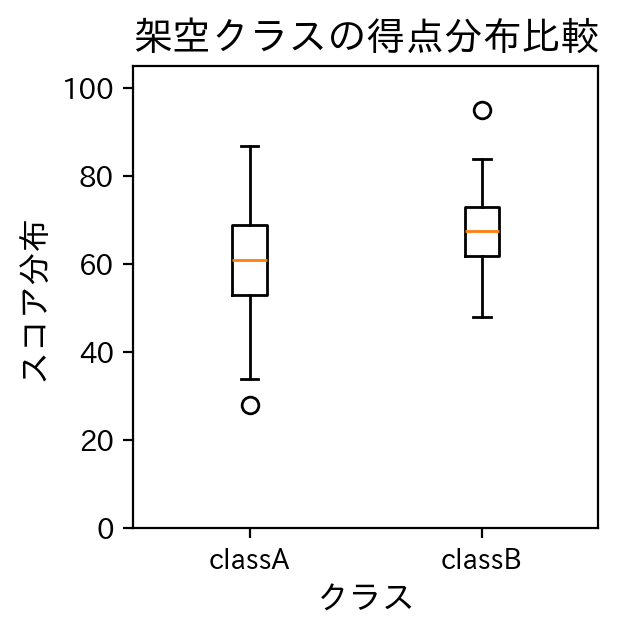

In [25]:
# 比較のため、箱ひげ図も書いてみる

# スコアデータ
scores = [classA_score, classB_score]

# 箱ひげ図の作成
plt.figure(figsize=(3,3))
plt.boxplot(scores)
plt.xticks([1, 2], ['classA', 'classB'])

plt.title('架空クラスの得点分布比較', fontsize=14)
plt.xlabel('クラス', fontsize=12)
plt.ylabel('スコア分布', fontsize=12)
plt.ylim([0,105])
plt.grid(False)

# グラフ描画
plt.show()

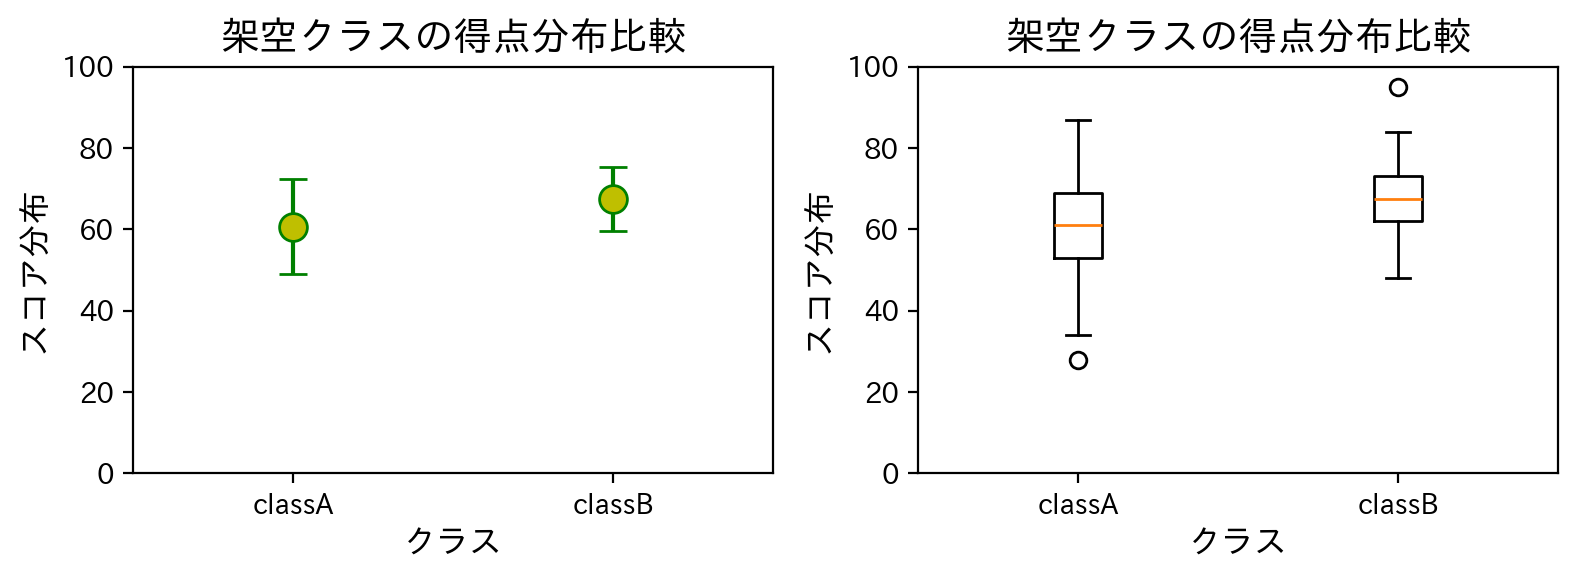

In [26]:
# 複数グラフ全体の描画範囲を指定
plt.figure(figsize=(8,3))

# 1x2 （縦1、横2）のグラフの 1番目のグラフ作成
plt.subplot(1, 2, 1)

# データ作成（乱数生成データ）
classes = ['classA', 'classB']
mean_score = [mean_A, mean_B]
errorbar = [std_A, std_B]

# エラーバー付き散布図の作成
plt.errorbar(classes, mean_score, yerr=errorbar, capsize=5, fmt='o', markersize=10, ecolor='g', markeredgecolor="g", color='y')

# グラフ軸範囲指定
plt.xlim(-0.5, 1.5)
plt.ylim(0, 100)

# グラフタイトル及び各軸の名称
plt.title('架空クラスの得点分布比較', fontsize=14)
plt.xlabel('クラス', fontsize=12)
plt.ylabel('スコア分布', fontsize=12)

# 1x2 （縦1、横2）のグラフの 2番目のグラフ作成
plt.subplot(1, 2, 2)

# スコアデータ
scores = [classA_score, classB_score]

# 箱ひげ図の作成
plt.boxplot(scores)
plt.xticks([1, 2], ['classA', 'classB'])

# タイトル、軸範囲の設定
plt.title('架空クラスの得点分布比較', fontsize=14)
plt.xlabel('クラス', fontsize=12)
plt.ylabel('スコア分布', fontsize=12)
plt.ylim(0,100)

# 複数グラフの一括表示
plt.tight_layout()
plt.show()

### 前回の演習課題解答例

In [27]:
# 乱数によるデータ生成（正規分布に従うデータ）
rng = np.random.default_rng() # seedの設定（空も可）
height01 = rng.normal(160, 1, 30)
height02 = rng.normal(168, 1.2, 30)

In [28]:
# 平均値の計算
mean_A = height01.mean()
mean_B = height02.mean()

# 標準偏差（誤差棒の長さ）の計算
std_A = height01.std()
std_B = height02.std()

print(mean_A, std_A)
print(mean_B, std_B)

160.19519865211558 1.1921102954601965
168.10130087602482 1.17391177476695


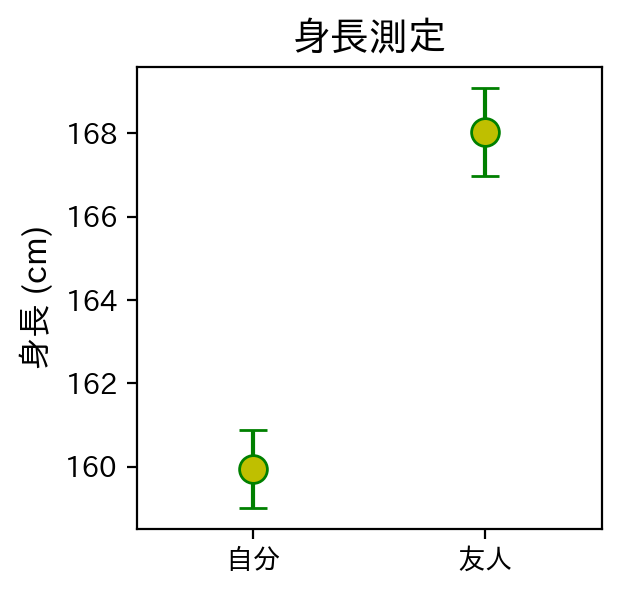

In [29]:
# 乱数によるデータ生成（正規分布に従うデータ）
rng = np.random.default_rng() # seedの設定（空も可）
height01 = rng.normal(160, 1, 30)
height02 = rng.normal(168, 1.2, 30)

# 平均値の計算
mean_A = height01.mean()
mean_B = height02.mean()

# 標準偏差（誤差棒の長さ）の計算
std_A = height01.std()
std_B = height02.std()

# データ作成（乱数生成データ）
classes = ['自分', '友人']
mean_score = [mean_A, mean_B]
errorbar = [std_A, std_B]

# 散布図の作成
plt.figure(figsize=(3,3))
#plt.scatter(classes, mean_score)

# エラーバー付き散布図の作成
plt.errorbar(classes, mean_score, yerr=errorbar, capsize=5, fmt='o', markersize=10, ecolor='g', markeredgecolor="g", color='y')

# グラフ軸範囲指定
plt.xlim(-0.5, 1.5)
#plt.ylim(0, 100)

# グラフタイトル及び各軸の名称
plt.title('身長測定', fontsize=14)
plt.ylabel('身長 (cm)', fontsize=12)

# グラフ描画
plt.show()

### 前回演習の解説

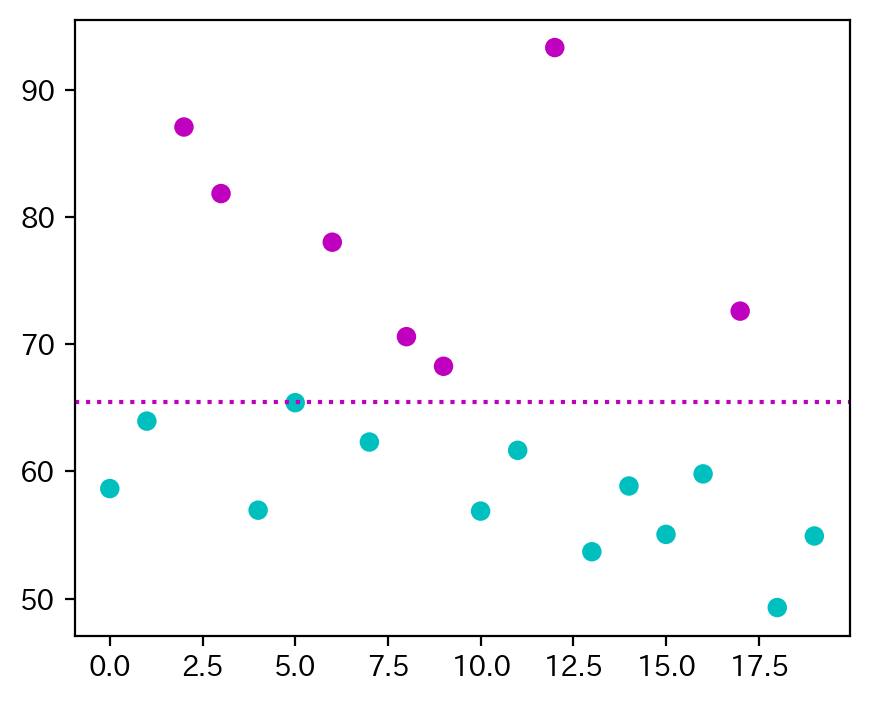

In [30]:
# 固定した乱数の生成
rng = np.random.default_rng(348309421) # seedの設定（空も可）
data = rng.normal(65, 15, 20)  # 平均65，標準偏差15の正規分布の乱数20個の配列

# マーカー色分け用の色リスト作成
mycolor = []
mean = data.mean()

for k in data:
    if k > mean:
        mycolor.append('m')
    else:
        mycolor.append('c')

# 散布図作成
plt.figure(figsize=(5,4))
plt.scatter(range(len(data)), data, marker='o', c=mycolor)

# 水平補助線
plt.axhline(y=data.mean(), c='m', ls=':')

# グラフ描画
plt.show()

['m', 'c', 'm', 'c', 'm']


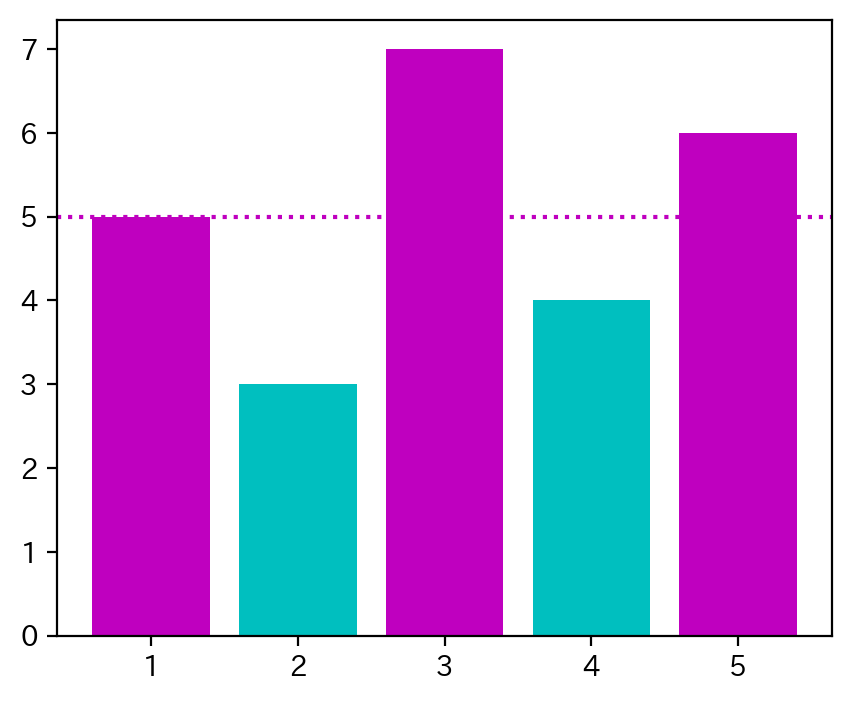

In [31]:
# データ
x = np.array([1, 2, 3, 4, 5])
y = np.array([5, 3, 7, 4, 6])

# マーカー色分け用の色リスト作成
mycolor = []
mean = y.mean()

for k in y:
    if k>=mean:
        mycolor.append('m')
    else:
        mycolor.append('c')
print(mycolor)

# 棒グラフの作成
plt.figure(figsize=(5,4))
plt.bar(x, y, color = mycolor)

# 水平補助線
plt.axhline(y=y.mean(), c='m', ls=':')

# グラフ描画
plt.show()

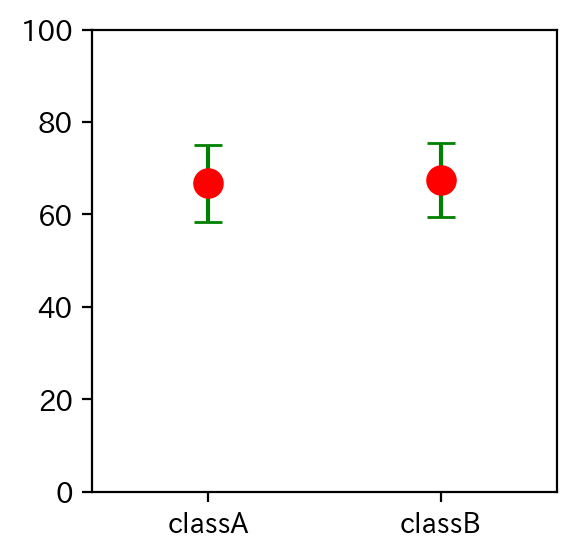

In [32]:
import numpy as np
import matplotlib.pyplot as plt

classA_score = [77,69,63,48,66,65,69,72,67,72,71,63,77,66,64,61,57,58,65,64,72,66,67,
                65,64,75,85,73,66,61,71,49,67,76,61,51,66,67,65,52,76,72,73,58,78,58,
                60,52,57,73,63,69,81,67,64,61,60,58,75,48,66,67,59,67,58,78,88,64,69,
                80,72,72,84,75,57,77,80,63,69,54,57,68,64,64,52,66,74,75,65,79,72,66,
                77,68,52,63,59,77,71,68]

classB_score = [57,76,75,62,66,57,70,67,78,67,55,72,79,61,56,76,72,69,71,76,69,71,73,
                67,67,71,58,65,74,69,77,74,75,77,65,73,84,66,63,53,56,71,63,63,68,70,
                77,69,73,62,64,57,79,79,64,57,66,83,64,61,68,57,48,69,67,57,58,71,73,
                74,68,56,71,58,63,80,67,60,68,67,55,59,51,63,71,75,71,61,95,67,71,68,
                72,61,67,73,60,65,81,64]

classname = ['classA', 'classB']   # 2クラスの名前リスト
mean_score = [np.mean(classA_score), np.mean(classB_score)]  # 2クラス分の平均点のリスト
errorbar = [np.std(classA_score), np.std(classB_score)]    # 2クラス分の標準偏差のリスト

plt.figure(figsize=(3,3))
plt.errorbar(classname, mean_score, yerr=errorbar, capsize=5, fmt='o', markersize=10, ecolor='g', markeredgecolor='r', color='r')
plt.xlim(-0.5, 1.5)
plt.ylim(0, 100)
plt.show()

In [34]:
mean_score

[np.float64(66.72), np.float64(67.49)]

In [35]:
errorbar

[np.float64(8.369085971598093), np.float64(7.963033341635584)]

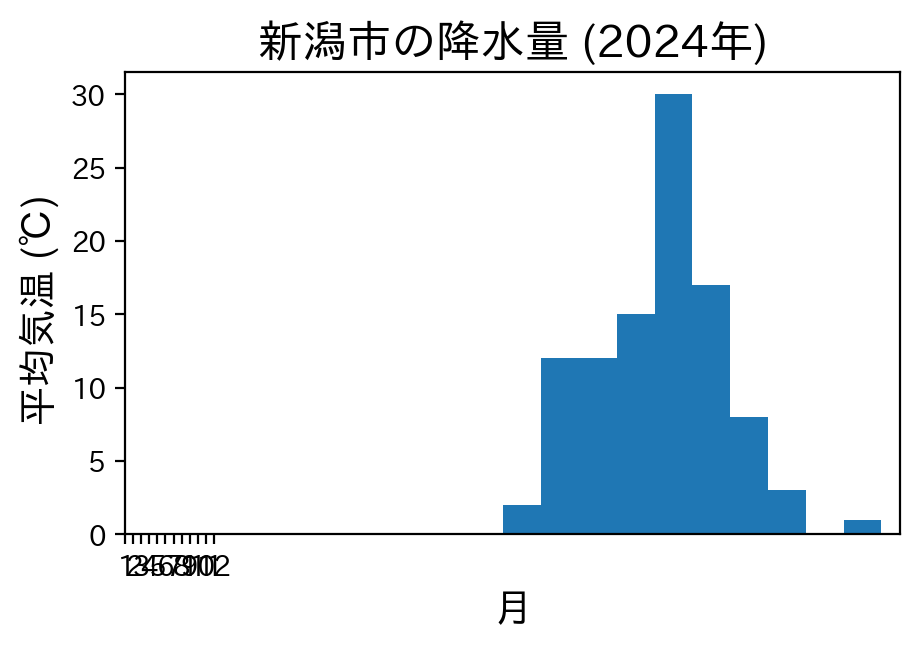

In [42]:
# データ準備（.to_numpy() はなくてもよい！)
month = df['月']
rain = df['降水量']
temp = df['平均気温']

# 棒グラフの作成
plt.figure(figsize=(5,3))

# グラフの種類を並べてみる

# 1引数でOKなグラフ
# plt.plot(temp)

# 2引数必要なグラフ
# plt.bar(month, temp)
# plt.scatter(month, temp)

data = [57,76,75,62,66,57,70,67,78,67,55,72,79,61,56,76,72,69,71,76,69,71,73,
        67,67,71,58,65,74,69,77,74,75,77,65,73,84,66,63,53,56,71,63,63,68,70,
        77,69,73,62,64,57,79,79,64,57,66,83,64,61,68,57,48,69,67,57,58,71,73,
        74,68,56,71,58,63,80,67,60,68,67,55,59,51,63,71,75,71,61,95,67,71,68,
        72,61,67,73,60,65,81,64]

plt.hist(data)


# 必要な情報追加
plt.title('新潟市の降水量 (2024年)', fontsize=16)
plt.xlabel('月', fontsize=14)
plt.ylabel("平均気温 (℃) ", fontsize=14)
plt.xticks(range(1,13))

# グラフ描画
plt.show()

In [51]:
df


,月,降水量,平均気温
0,1,180.0,4.3
1,2,114.5,4.8
2,3,168.0,6.0
3,4,54.0,13.7
4,5,128.0,17.1
5,6,57.0,22.2
6,7,376.5,26.2
7,8,42.0,28.0
8,9,292.0,25.0
9,10,144.5,18.7


In [55]:
print(df['平均気温'].tolist())

[4.3, 4.8, 6.0, 13.7, 17.1, 22.2, 26.2, 28.0, 25.0, 18.7, 11.5, 4.9]
